# Model Exploration

This notebook is the trial-and-error workspace for Part II modeling (see `CONVENTIONS.md`). The final, clean version — refactored into functions — moves to `model_pipeline/` once the approach is settled.

## Step 1: train/test split

**Is it necessary to split before imputing? Yes — and it is worth being explicit about why.** Any statistic used to fill missing values (a median, a category frequency) has to be *fit* on some data. If that data includes the test set, the test set has quietly influenced training, so the later evaluation is no longer a clean estimate of how the model performs on data it has never seen. The correct order is: split first, then fit every preprocessing step (imputer, encoder, and later the model itself) only on the training data, and only ever *apply* — never *fit* — those same fitted steps to the test data. This is why the split happens in this cell, before the `ColumnTransformer` in Step 2 is even built.

The four columns that will be imputed each have exactly 30 nulls in the full 1,000-row dataset (3.0% each, per `EDA_report.md`): `Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs`. `Order_ID` is dropped as a plain identifier with no predictive value, and the target is separated out before the split.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/Food_Delivery_Times.csv")

X = df.drop(columns=["Order_ID", "Delivery_Time_min"])
y = df["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (800, 7), X_test: (200, 7)
y_train: (800,), y_test: (200,)


In [2]:
impute_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Courier_Experience_yrs"]

null_breakdown = pd.DataFrame({
    "n_null_full": df[impute_cols].isnull().sum(),
    "pct_null_full": (df[impute_cols].isnull().mean() * 100).round(1),
    "n_null_train": X_train[impute_cols].isnull().sum(),
    "pct_null_train": (X_train[impute_cols].isnull().mean() * 100).round(1),
    "n_null_test": X_test[impute_cols].isnull().sum(),
    "pct_null_test": (X_test[impute_cols].isnull().mean() * 100).round(1),
})
null_breakdown

,n_null_full,pct_null_full,n_null_train,pct_null_train,n_null_test,pct_null_test
Weather,30,3.0,22,2.8,8,4.0
Traffic_Level,30,3.0,19,2.4,11,5.5
Time_of_Day,30,3.0,24,3.0,6,3.0
Courier_Experience_yrs,30,3.0,24,3.0,6,3.0


The 3.0% null rate holds exactly in the full dataset, but the random split does **not** reproduce that 3.0% identically in train and test — e.g. `Traffic_Level` is 2.4% null in train vs. 5.5% in test, and `Weather` is 2.8% vs. 4.0%. This is expected sampling variation from a single random 80/20 split, and it is itself part of why train and test have to stay separate: they are not identical copies of each other, so a statistic fit on one is not automatically valid for the other.

**A concrete illustration of the leakage risk**, using `Courier_Experience_yrs`: the median computed on the full 1,000-row dataset is **5.0**, identical to the median computed on the 800-row training split alone (**5.0**) — for this particular column and split, imputing "the wrong way" would happen to produce the same fill value. But the *mean* tells a different story: **4.579** on the full dataset vs. **4.607** on the training split alone — a small but real difference (≈ -0.03). The median coinciding here is a property of this specific dataset (coarse, integer-like values), not a guarantee; the mean shows the underlying mechanism plainly, and with a smaller dataset, a different split, or a different imputation statistic, the gap would not necessarily stay this small. This is exactly the leakage `X_train`/`X_test` avoids: every fitted value used later comes only from the 800 training rows.

## Step 2: preprocessing pipeline (now in `model_pipeline/`)

The `ColumnTransformer` validated earlier in this notebook has been moved into `model_pipeline/data_preprocessing.py`, behind a `build_preprocessing_pipeline()` function, with the feature lists, the `Traffic_Level` category order, and the split settings (`RANDOM_STATE`, `TEST_SIZE`) factored out into `model_pipeline/config.py`. This notebook now imports that function instead of redefining the transformer inline — the same exploration-to-deliverable move `CONVENTIONS.md` describes for every other part of this project.

The reasoning behind `Traffic_Level`'s `"Unknown"` position (placed after `High`, backed by the 62.1 vs. 56.6 min gap between null and non-null rows found in the EDA) now lives as a comment in `model_pipeline/config.py`, next to the constant it explains, rather than only here.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))  # project root, so `model_pipeline` is importable from notebooks/

from model_pipeline.config import NUMERIC_FEATURES
from model_pipeline.data_preprocessing import build_preprocessing_pipeline

preprocessor = build_preprocessing_pipeline()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

That output is `scikit-learn`'s interactive HTML diagram (its default rendering for estimators in a Jupyter notebook, not just printed text) — every box is clickable/expandable, showing the exact nesting of the `ColumnTransformer`, its three named branches, and each `Pipeline`'s steps with their fitted parameters. It is a genuinely useful sanity check on its own: a quick visual scan confirms each column list is routed to the right imputer/encoder pair before anything is actually fit, catching a mis-wired transformer far faster than reading the constructor code line by line.

## Step 3: quick validation

`fit_transform` is called only on `X_train`, so every fitted value (the medians, the one-hot categories seen) comes exclusively from training data. `X_test` is only ever `transform`-ed, never fit.

In [4]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed: {X_train_transformed.shape}")
print(f"X_test_transformed: {X_test_transformed.shape}")
print(f"Nulls remaining in train: {np.isnan(X_train_transformed).sum()}")
print(f"Nulls remaining in test: {np.isnan(X_test_transformed).sum()}")

X_train_transformed: (800, 15)
X_test_transformed: (200, 15)
Nulls remaining in train: 0
Nulls remaining in test: 0


In [5]:
preprocessor.get_feature_names_out()

array(['numeric__Distance_km', 'numeric__Preparation_Time_min',
       'numeric__Courier_Experience_yrs', 'ordinal__Traffic_Level',
       'nominal__Weather_Foggy', 'nominal__Weather_Rainy',
       'nominal__Weather_Snowy', 'nominal__Weather_Unknown',
       'nominal__Weather_Windy', 'nominal__Time_of_Day_Evening',
       'nominal__Time_of_Day_Morning', 'nominal__Time_of_Day_Night',
       'nominal__Time_of_Day_Unknown', 'nominal__Vehicle_Type_Car',
       'nominal__Vehicle_Type_Scooter'], dtype=object)

15 output columns from the 7 input columns: 3 numeric (imputed, unchanged in count) + 1 ordinal (`Traffic_Level`, encoded to a single numeric column) + 11 one-hot columns from the 3 nominal features. Each nominal column is encoded with `drop="first"`, so one category per group becomes an implicit reference level instead of getting its own column: `Weather` keeps 5 of its 6 categories (`Clear` is the reference), `Time_of_Day` keeps 4 of its 5 (`Afternoon` is the reference), `Vehicle_Type` keeps 2 of its 3 (`Bike` is the reference). This is what keeps the design matrix from becoming rank-deficient once an intercept is added — see Step 6. No model has been trained yet — that is the next step.

## Step 4: missing-value check and post-transformation summary statistics

The transformed arrays are wrapped into DataFrames using `preprocessor.get_feature_names_out()` for column labels — this is only for inspection here, not part of the pipeline itself. A per-column missing-value count (not just the single total already shown in Step 3) confirms exactly which columns are clean, and `describe()` gives a short statistical summary of every transformed variable, for both the training and test sets.

In [6]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

missing_check = pd.DataFrame({
    "n_missing_train": X_train_df.isnull().sum(),
    "n_missing_test": X_test_df.isnull().sum(),
})

assert missing_check["n_missing_train"].sum() == 0
assert missing_check["n_missing_test"].sum() == 0
print("Confirmed: 0 missing values in every column, both train and test.")
missing_check

Confirmed: 0 missing values in every column, both train and test.


,n_missing_train,n_missing_test
numeric__Distance_km,0,0
numeric__Preparation_Time_min,0,0
numeric__Courier_Experience_yrs,0,0
ordinal__Traffic_Level,0,0
nominal__Weather_Foggy,0,0
nominal__Weather_Rainy,0,0
nominal__Weather_Snowy,0,0
nominal__Weather_Unknown,0,0
nominal__Weather_Windy,0,0
nominal__Time_of_Day_Evening,0,0


In [7]:
X_train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
numeric__Distance_km,800.0,10.10055,5.725900,0.59,5.13,10.22,14.9425,19.99
numeric__Preparation_Time_min,800.0,17.08375,7.227519,5.00,11.00,17.00,23.0000,29.00
numeric__Courier_Experience_yrs,800.0,4.61875,2.902832,0.00,2.00,5.00,7.0000,9.00
ordinal__Traffic_Level,800.0,0.85750,0.814262,0.00,0.00,1.00,1.0000,3.00
nominal__Weather_Foggy,800.0,0.10250,0.303494,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Rainy,800.0,0.20500,0.403954,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Snowy,800.0,0.09625,0.295118,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Unknown,800.0,0.02750,0.163637,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Windy,800.0,0.10000,0.300188,0.00,0.00,0.00,0.0000,1.00
nominal__Time_of_Day_Evening,800.0,0.29500,0.456328,0.00,0.00,0.00,1.0000,1.00


The numeric columns look consistent with the EDA (e.g. `Distance_km` mean ≈ 10.10, `Preparation_Time_min` mean ≈ 17.08), now with no nulls left to fill. `ordinal__Traffic_Level` ranges from 0 to 3 as expected (`Low`-`Unknown`), with a mean of 0.86 — pulled toward the low end, since `Low` and `Medium` are the two largest categories. Every one-hot column is a proportion between 0 and 1, and each mean matches its category's share of the training data — e.g. `nominal__Weather_Rainy` ≈ 0.21 lines up with `Rainy` being roughly a fifth of all rows, and the small `_Unknown` means (`Weather` ≈ 0.03, `Time_of_Day` ≈ 0.03) line up with the ~3% null rate found in the EDA, now carried through as their own category instead of a missing value. Note that `Weather`, `Time_of_Day`, and `Vehicle_Type`'s reference categories (`Clear`, `Afternoon`, `Bike`) do not appear as columns here at all — `drop="first"` (see Step 3) means they are represented implicitly, as the case where every other dummy in their group is 0.

## Step 5: does imputation preserve the original statistical properties?

This compares each column's statistics on `X_train` *before* imputation (computed only on the non-null rows, via `.dropna()`) against the same column *after* imputation — both on the training split, so the comparison is fair and like-for-like. The goal is to check directly whether filling missing values changed the data's behavior, rather than assuming it did not.

In [8]:
numeric_comparison = []
for c in NUMERIC_FEATURES:
    before = X_train[c].dropna()
    after = X_train_df[f"numeric__{c}"]
    numeric_comparison.append({
        "column": c,
        "n_missing": len(after) - len(before),
        "mean_before": before.mean(), "mean_after": after.mean(),
        "median_before": before.median(), "median_after": after.median(),
        "std_before": before.std(), "std_after": after.std(),
        "std_change_pct": 100 * (after.std() - before.std()) / before.std(),
    })

pd.DataFrame(numeric_comparison).round(3)

,column,n_missing,mean_before,mean_after,median_before,median_after,std_before,std_after,std_change_pct
0,Distance_km,0,10.101,10.101,10.22,10.22,5.726,5.726,0.000
1,Preparation_Time_min,0,17.084,17.084,17.00,17.00,7.228,7.228,0.000
2,Courier_Experience_yrs,24,4.607,4.619,5.00,5.00,2.947,2.903,-1.487


In [9]:
for c, prefix in [("Weather", "Weather"), ("Time_of_Day", "Time_of_Day"), ("Vehicle_Type", "Vehicle_Type")]:
    before_pct = (X_train[c].value_counts(normalize=True, dropna=True) * 100).round(2)
    after_cols = [col for col in X_train_df.columns if col.startswith(f"nominal__{prefix}_")]
    after_pct = (X_train_df[after_cols].mean() * 100).round(2)
    after_pct.index = [i.replace(f"nominal__{prefix}_", "") for i in after_pct.index]
    print(f"\n{c}")
    print(pd.DataFrame({"before_pct": before_pct, "after_pct": after_pct}).fillna(0.0))


Weather
         before_pct  after_pct
Clear         48.20       0.00
Foggy         10.54      10.25
Rainy         21.08      20.50
Snowy          9.90       9.62
Unknown        0.00       2.75
Windy         10.28      10.00

Time_of_Day
           before_pct  after_pct
Afternoon       28.87        0.0
Evening         30.41       29.5
Morning         30.93       30.0
Night            9.79        9.5
Unknown          0.00        3.0

Vehicle_Type
         before_pct  after_pct
Bike          49.62       0.00
Car           20.38      20.38
Scooter       30.00      30.00


In [10]:
before_pct = (X_train["Traffic_Level"].value_counts(normalize=True, dropna=True) * 100).round(2)
after_pct = (
    X_train_df["ordinal__Traffic_Level"]
    .map({0: "Low", 1: "Medium", 2: "High", 3: "Unknown"})
    .value_counts(normalize=True) * 100
).round(2)

pd.DataFrame({"before_pct": before_pct, "after_pct": after_pct}).fillna(0.0)

,before_pct,after_pct
High,20.36,19.88
Low,39.82,38.88
Medium,39.82,38.88
Unknown,0.00,2.38


**The honest answer is: mostly, but not perfectly — imputation has small, real, measurable effects, not zero effect.**

- `Distance_km` and `Preparation_Time_min` have no missing values at all, so there is nothing to compare — before and after are identical by construction.
- `Courier_Experience_yrs` (24 imputed rows in `X_train`, ~3%): the **mean is nearly unchanged** (4.607 → 4.619, a +0.012 shift) and the **median is exactly unchanged** (5.0 → 5.0, since the imputed values *are* the median). But the **standard deviation shrinks by ~1.5%** (2.947 → 2.903). This is the expected mechanical effect of median imputation: replacing missing values with a single constant removes variation that would otherwise have been there, slightly compressing the spread. At a 3% missing rate the effect is small, but it is not zero, and it would grow if the missing rate were higher.
- `Weather`, `Time_of_Day`, and `Traffic_Level` (each ~3% missing): introducing `"Unknown"` as its own category necessarily **dilutes every other category's share by roughly the missing rate** — e.g. `Weather`'s `Rainy` share drops from 21.08% (among non-null rows) to 20.50% (once `Unknown` claims its own 2.75%); `Traffic_Level`'s `Low` and `Medium` each drop by about 1 point. The *relative ordering* of categories is preserved, but their *exact* proportions are not — by design, since `"Unknown"` was never part of the original category distribution and is now competing for share with the real ones.
- `Vehicle_Type` has no missing values, so it is unchanged, as expected.

So imputation does not leave the data's behavior completely untouched: it modestly compresses the numeric column's spread and dilutes categorical proportions in proportion to how much was missing. Given the missing rate here is only ~3% per affected column, these shifts are small — but they are a real, if minor, trade-off of the chosen strategy, not something to claim is fully preserved.

One more thing visible in the `Weather`/`Time_of_Day`/`Vehicle_Type` tables above, unrelated to imputation: `Clear`, `Afternoon`, and `Bike` show `after_pct = 0.0`. That is not a second dilution effect — it is `drop="first"` (see Step 3) removing their dedicated columns entirely, since they are each their group's reference category. Their true share of the data is unchanged; it is just no longer represented by a column of its own, so `X_train_df[after_cols].mean()` has nothing to compute for them.

## Step 6: baseline model (`statsmodels` OLS)

`statsmodels.OLS` is used instead of `sklearn`'s linear regression for this baseline specifically to get p-values, adjusted R², and confidence intervals per coefficient out of the box via `.summary()` — `sklearn`'s `LinearRegression` does not expose these directly. This is the baseline: no interaction terms, no polynomial terms, just the 15 preprocessed features plus an intercept (`sm.add_constant`). Interactions and other extensions are a separate step, after these results are reviewed.

One alignment detail worth being explicit about: `X_train_df` was built from a transformed `numpy` array in Step 4, so it has a fresh `0..799` index, while `y_train` still carries the original row index from the train/test split. `.reset_index(drop=True)` on `y_train` (and later `y_test`) makes both sides line up by position, which is what is actually needed here, since `X_train_df` and `y_train` were produced from the same row order to begin with.

In [11]:
import statsmodels.api as sm

y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

X_train_const = sm.add_constant(X_train_df)
baseline_model = sm.OLS(y_train_reset, X_train_const).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_min   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     170.6
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          9.30e-235
Time:                        22:57:18   Log-Likelihood:                -3037.5
No. Observations:                 800   AIC:                             6107.
Df Residuals:                     784   BIC:                             6182.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

**Headline numbers:** R² = 0.765, Adj. R² = 0.761 — the baseline explains about three-quarters of the variance in `Delivery_Time_min` on the training data. `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and `Traffic_Level` all have very small p-values (< 0.001), consistent with `Distance_km`'s strong correlation (r ≈ 0.78) and `Traffic_Level`'s clear gradient found in the EDA. `Cond. No.` is now 139, and there is no singular-matrix note in the output — a first sign the dummy variable trap discussed below is actually fixed (confirmed formally by `compute_vif` further down).

**Every categorical coefficient is now interpretable relative to its group's reference category** (`Clear` for `Weather`, `Afternoon` for `Time_of_Day`, `Bike` for `Vehicle_Type` — the categories `drop="first"` removed in Step 3). For example, `nominal__Weather_Snowy` = +9.27 (p < 0.001): a `Snowy` delivery averages ~9.3 more minutes than an otherwise-identical `Clear` one, holding everything else constant — in the same direction as, and a similar magnitude to, the +14 min gap found directly in the EDA between those two conditions. `Weather_Rainy` (+5.02, p < 0.001) and `Weather_Foggy` (+6.26, p < 0.001) are also significant; `Weather_Windy` (+1.36, p = 0.316) is not, again consistent with `Windy` sitting close to `Clear` in the EDA. None of the `Vehicle_Type` or `Time_of_Day` dummies are significant except `Time_of_Day_Unknown` (+7.69, p = 0.001) — matching the EDA finding that missing `Time_of_Day` rows had a notably higher average delivery time.

This is worth contrasting with the *earlier* version of this baseline (before `drop="first"` was added to `OneHotEncoder` in `model_pipeline/data_preprocessing.py`): that version had `Cond. No.` = 2.59e+17 and a `RuntimeWarning: divide by zero`, from an exactly rank-deficient design matrix (every nominal column's dummies summed to 1, duplicating the intercept). R², AIC, and the fitted values were identical then and now — a perfectly redundant column cannot add or remove predictive information — but the individual categorical coefficients and p-values were not uniquely determined and could not be trusted. That is the specific problem `drop="first"` fixes, without changing the model's predictions at all.

## Step 7: applying the reusable diagnostics

The 6 functions in `model_pipeline/model_diagnostics.py` all take an already-fitted `statsmodels` results object (or the specific data a given check needs), so the same functions can be re-run unchanged on any later model version for a like-for-like comparison against this baseline.

In [12]:
import matplotlib.pyplot as plt

from model_pipeline.model_diagnostics import (
    breusch_pagan_test,
    compute_test_metrics,
    compute_vif,
    get_aic,
    plot_residuals_vs_fitted,
    qq_plot,
)

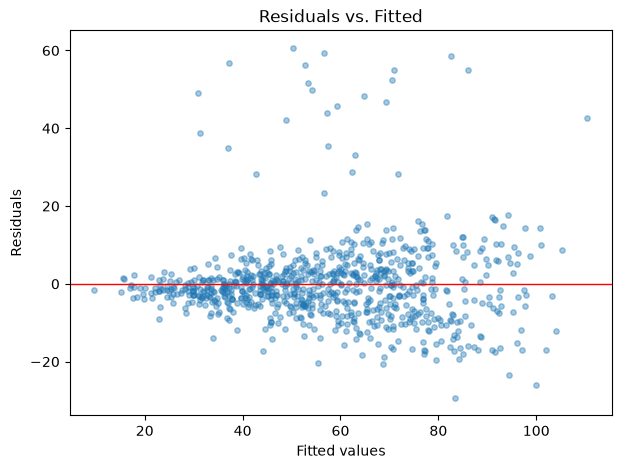

In [13]:
plot_residuals_vs_fitted(baseline_model)
plt.show()

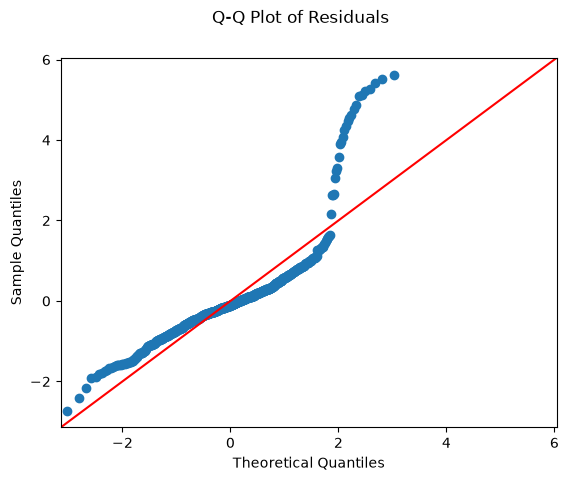

In [14]:
qq_plot(baseline_model)
plt.show()

The model summary's own `Omnibus`/`Jarque-Bera` block already hints at what these two plots confirm visually: skew ≈ 2.43 and kurtosis ≈ 13.3 (a normal distribution has skew 0, kurtosis 3), with `Prob(JB)` ≈ 0.00 — strong evidence against normally-distributed residuals. The Q-Q plot's upper tail bows well above the 45° reference line (the largest positive residuals are far more extreme than a normal distribution would predict, while the lower tail stays close to the line), and the residuals-vs-fitted plot shows that same asymmetry directly: a dense, roughly symmetric band of points near zero, plus a scatter of large *positive* residuals (up to +60) reaching well above it, with no comparable cluster on the negative side. This lines up with the target's own right skew (≈ 0.51) and the 6 IQR outliers found on `Delivery_Time_min` in the EDA — a handful of unusually slow deliveries the baseline is systematically under-predicting.

In [15]:
bp_results = breusch_pagan_test(baseline_model)
bp_results

{'lm_statistic': np.float64(30.30298863405383),
 'lm_p_value': np.float64(0.010874645314038625),
 'f_statistic': np.float64(2.057739841199484),
 'f_p_value': np.float64(0.010166978109844398)}

Both p-values are below 0.05 (LM p ≈ 0.011, F p ≈ 0.010), so the null hypothesis of homoscedasticity (constant residual variance) is rejected at the conventional 5% level. The LM statistic itself (≈ 30.30) is exactly the same as it would be with the redundant one-hot columns still present — removing perfectly collinear columns cannot change the residuals — but its p-value is smaller now (0.011 vs. 0.035 with the un-fixed encoding), because the chi-square reference distribution's degrees of freedom depend on the number of predictors in the auxiliary regression (14 now vs. 17 before), and the extra 3 before were not contributing distinct information. This is a real, if not overwhelming, signal that the residual spread is not fully constant across the range of fitted values, likely connected to the same right-skewed target/residual pattern seen above. Worth keeping in mind if standard errors and p-values are used for inference later: heteroscedasticity does not bias the coefficients themselves, but it can make the usual (nonrobust) standard errors unreliable.

In [16]:
vif_table = compute_vif(X_train_df)
vif_table

,feature,VIF
0,numeric__Distance_km,1.018386
1,numeric__Preparation_Time_min,1.018526
2,numeric__Courier_Experience_yrs,1.022513
3,ordinal__Traffic_Level,1.014313
4,nominal__Weather_Foggy,1.103601
5,nominal__Weather_Rainy,1.155682
6,nominal__Weather_Snowy,1.107580
7,nominal__Weather_Unknown,1.044534
8,nominal__Weather_Windy,1.116123
9,nominal__Time_of_Day_Evening,1.456429


This confirms the fix directly: **every VIF is now finite**, and all of them are low. `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and `Traffic_Level` sit at ≈ 1.0-1.02 (a VIF near 1 means "no inflation at all," matching the EDA's near-zero pairwise correlations, |r| ≤ 0.03, among the numeric features). The one-hot columns are a bit higher, as expected for dummies that share information within their group (e.g. `Time_of_Day_Evening` and `Time_of_Day_Morning` at ≈ 1.46, the highest in the table), but nowhere near a concerning level — a common rule of thumb flags VIF > 5 or > 10, and the maximum here is ≈ 1.46. With `drop="first"` in place, the `Weather`, `Time_of_Day`, and `Vehicle_Type` coefficients and p-values in the Step 6 summary can now be read at face value.

In [17]:
baseline_aic = get_aic(baseline_model)
print(f"Baseline AIC: {baseline_aic:.2f}")

Baseline AIC: 6106.94


This AIC (≈ 6106.94) is only meaningful in comparison to another model fit on the exact same training rows and target — it is the number future model versions (with interactions, different encodings, etc.) will be compared against.

In [18]:
X_test_const = sm.add_constant(X_test_df, has_constant="add")
y_pred = baseline_model.predict(X_test_const)

test_metrics = compute_test_metrics(y_test_reset, y_pred)
test_metrics

{'MAE': 6.18457162234078, 'RMSE': np.float64(9.054303230437576)}

MAE ≈ 6.18 min and RMSE ≈ 9.05 min on the held-out test set. RMSE being noticeably larger than MAE (rather than close to it) is consistent with the skewed-residuals finding above: a few large errors are pulling the squared-error metric up more than the absolute-error one.

## Baseline summary

This is the starting point for comparison, not a final model:

- **R² / Adj. R²:** 0.765 / 0.761
- **AIC:** ≈ 6106.94
- **Test MAE / RMSE:** ≈ 6.18 min / 9.05 min
- **Breusch-Pagan:** p ≈ 0.011 (LM) — a real, if not overwhelming, signal of heteroscedasticity
- **VIF:** all finite and low (≈ 1.0-1.46 across every feature) — `OneHotEncoder(drop="first")` fixed the dummy variable trap found in the first pass at this baseline (where every one-hot column had `VIF = inf`), and every categorical coefficient and p-value in the Step 6 summary can now be trusted
- **Residuals:** right-skewed and heavy-tailed (skew ≈ 2.43, kurtosis ≈ 13.3), not normal — tied to the same handful of slow-delivery outliers flagged in the EDA; this is still unresolved

No interaction or polynomial terms have been added yet — that is deliberately left for the next step, once these results are reviewed. The remaining open issues are the residual non-normality/heteroscedasticity above, not the encoding, which is now fixed.

## Step 8: advanced regression, with interaction terms

Four interaction terms are added to the baseline's 15 features: `Distance_km × Traffic_Level`, `Distance_km × Weather`, `Courier_Experience_yrs × Weather`, and `Courier_Experience_yrs × Traffic_Level`. The choice of these specific interactions — courier-level information crossed with contextual conditions — is adapted from Fu, Chi, Zheng & Shen (2025)'s Deep & Cross Network approach to delivery-time prediction; the full justification, including why that paper's architecture itself is not used here, is documented in `model_notes.md`.

Since `Weather` and `Traffic_Level` are already encoded (one-hot and ordinal, respectively) from Step 2, each interaction is built as a literal column-wise product on the already-transformed features. `Distance_km × Weather` and `Courier_Experience_yrs × Weather` each expand into 5 separate product columns, one per `Weather` dummy — `Weather`'s reference category, `Clear`, has no column of its own (see Step 3), so there is no interaction term for it either, consistent with `Clear` being the implicit baseline case throughout.

In [19]:
def add_interaction_terms(X):
    X = X.copy()
    weather_cols = [c for c in X.columns if c.startswith("nominal__Weather_")]

    X["Distance_km_x_Traffic_Level"] = X["numeric__Distance_km"] * X["ordinal__Traffic_Level"]
    for c in weather_cols:
        label = c.replace("nominal__Weather_", "")
        X[f"Distance_km_x_Weather_{label}"] = X["numeric__Distance_km"] * X[c]
    for c in weather_cols:
        label = c.replace("nominal__Weather_", "")
        X[f"Courier_Experience_yrs_x_Weather_{label}"] = X["numeric__Courier_Experience_yrs"] * X[c]
    X["Courier_Experience_yrs_x_Traffic_Level"] = X["numeric__Courier_Experience_yrs"] * X["ordinal__Traffic_Level"]

    return X


X_train_adv = add_interaction_terms(X_train_df)
X_test_adv = add_interaction_terms(X_test_df)

print(f"X_train_adv: {X_train_adv.shape}, X_test_adv: {X_test_adv.shape}")

X_train_adv: (800, 27), X_test_adv: (200, 27)


27 columns: the 15 from the baseline plus 12 interaction terms (1 `Distance_km × Traffic_Level` + 5 `Distance_km × Weather` + 5 `Courier_Experience_yrs × Weather` + 1 `Courier_Experience_yrs × Traffic_Level`). Fitting follows the same pattern as the baseline.

In [20]:
X_train_adv_const = sm.add_constant(X_train_adv)
advanced_model = sm.OLS(y_train_reset, X_train_adv_const).fit()

print(advanced_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_min   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     96.10
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          8.01e-226
Time:                        22:57:18   Log-Likelihood:                -3028.5
No. Observations:                 800   AIC:                             6113.
Df Residuals:                     772   BIC:                             6244.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

R² = 0.771, Adj. R² = 0.763 — both a touch higher than the baseline (0.765 / 0.761), as expected from adding 12 more parameters that can only help the *in-sample* fit. But of the 12 interaction terms themselves, only one is statistically significant at the 5% level: `Courier_Experience_yrs_x_Weather_Unknown` (coef -1.65, p = 0.040). None of the hypothesized `Distance_km × Traffic_Level`, `Distance_km × Weather`, or `Courier_Experience_yrs × Traffic_Level` interactions reach significance, and the remaining `Courier_Experience_yrs × Weather` terms do not either. The one significant interaction involves `Weather_Unknown` — the ~3% originally-missing rows — which is more plausibly an artifact of that small, unusual subgroup than a genuine experience-by-weather effect. Taken together, this is a first sign that these particular interactions are not earning their added complexity; the diagnostics and the comparison table below make that more precise.

### Diagnostics, reused unchanged from `model_pipeline/model_diagnostics.py`

The same 6 functions applied to the baseline in Step 7 are called again here on `advanced_model` — no new diagnostic code, only a different fitted model passed in.

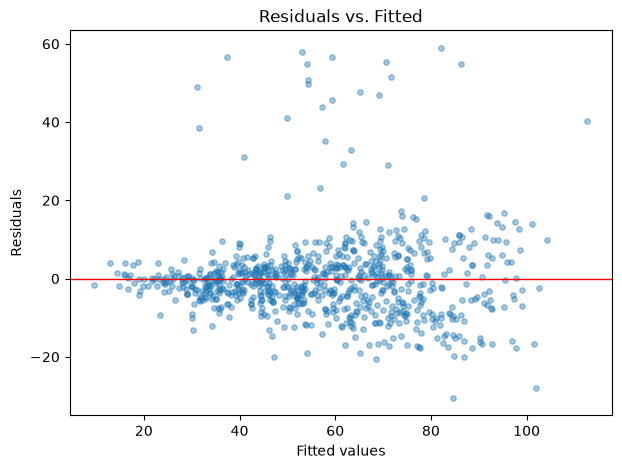

In [21]:
plot_residuals_vs_fitted(advanced_model)
plt.show()

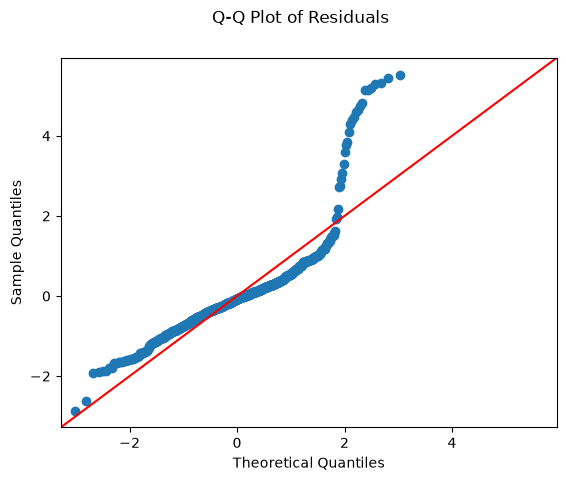

In [22]:
qq_plot(advanced_model)
plt.show()

Skew ≈ 2.38 and kurtosis ≈ 13.1 for `advanced_model` (vs. ≈ 2.43 / 13.3 for the baseline) — essentially the same right-skewed, heavy-tailed pattern, barely moved. The interaction terms were never going to fix this: they let the *slope* on `Distance_km`/`Courier_Experience_yrs` vary by category, but the handful of outlier deliveries driving the skew are extreme in `Delivery_Time_min` itself, not explained by a different slope in a linear model. Both plots should look close to indistinguishable from the baseline's.

In [23]:
bp_results_adv = breusch_pagan_test(advanced_model)
bp_results_adv

{'lm_statistic': np.float64(41.46989101880712),
 'lm_p_value': np.float64(0.03709471149910696),
 'f_statistic': np.float64(1.5631966150329395),
 'f_p_value': np.float64(0.03480485578794528)}

LM p ≈ 0.037, F p ≈ 0.035 — still below 0.05, so heteroscedasticity is still present. This is essentially the same conclusion as the baseline (LM p ≈ 0.011 there), just with a less extreme p-value; the interaction terms did not resolve it, nor would they be expected to, since they address the shape of the *mean* function, not the variance structure of the errors.

In [24]:
vif_table_adv = compute_vif(X_train_adv)
vif_table_adv.sort_values("VIF", ascending=False)

,feature,VIF
8,nominal__Weather_Windy,9.180509
5,nominal__Weather_Rainy,7.850252
6,nominal__Weather_Snowy,7.702944
3,ordinal__Traffic_Level,6.879514
4,nominal__Weather_Foggy,6.623535
17,Distance_km_x_Weather_Rainy,5.518481
15,Distance_km_x_Traffic_Level,5.415501
18,Distance_km_x_Weather_Snowy,5.267676
7,nominal__Weather_Unknown,5.057372
25,Courier_Experience_yrs_x_Weather_Windy,4.993219


**Yes — VIF rose meaningfully for exactly the variables that now have interaction partners, using the common VIF > 5 (moderate) / VIF > 10 (severe) rule of thumb.** `ordinal__Traffic_Level` goes from ≈ 1.01 in the baseline to ≈ 6.88 here; the `Weather` dummies go from ≈ 1.0-1.16 to a 5.06-9.18 range (`Weather_Windy` is the highest, at 9.18); `Distance_km` and `Courier_Experience_yrs` rise from ≈ 1.02 to ≈ 3.2-3.3 each. Several of the new interaction terms themselves also sit in the 3-5.5 range. Nothing crosses the severe (> 10) threshold, but multiple variables are now in the moderate-concern range, which the baseline had none of.

This is expected, and it is a different mechanism from the dummy-variable-trap fixed earlier: `Distance_km` and `Courier_Experience_yrs` were never centered before being multiplied into the interaction terms, so a variable and its own interaction term are mechanically correlated (e.g. `Distance_km` and `Distance_km × Traffic_Level` share the same `Distance_km` values scaled by a mostly-positive factor) — this is a well-known side effect of uncentered interactions, not a sign that `Distance_km` and `Traffic_Level` are themselves redundant (their own pairwise correlation is still near zero, per the EDA). Centering the continuous variables before building the interactions is a standard fix and would be worth trying if these interactions were kept, but is not applied here, consistent with reporting the diagnostics as they come out rather than pre-fixing them.

In [25]:
advanced_aic = get_aic(advanced_model)

X_test_adv_const = sm.add_constant(X_test_adv, has_constant="add")
y_pred_adv = advanced_model.predict(X_test_adv_const)
test_metrics_adv = compute_test_metrics(y_test_reset, y_pred_adv)

print(f"Advanced AIC: {advanced_aic:.2f}")
test_metrics_adv

Advanced AIC: 6112.96


{'MAE': 6.239115884239435, 'RMSE': np.float64(9.023932236863049)}

In [26]:
comparison = pd.DataFrame({
    "baseline": {
        "Adj_R2": baseline_model.rsquared_adj,
        "AIC": baseline_aic,
        "Test_MAE": test_metrics["MAE"],
        "Test_RMSE": test_metrics["RMSE"],
    },
    "advanced": {
        "Adj_R2": advanced_model.rsquared_adj,
        "AIC": advanced_aic,
        "Test_MAE": test_metrics_adv["MAE"],
        "Test_RMSE": test_metrics_adv["RMSE"],
    },
})
comparison.round(4)

,baseline,advanced
Adj_R2,0.7610,0.7627
AIC,6106.9406,6112.9582
Test_MAE,6.1846,6.2391
Test_RMSE,9.0543,9.0239


**The interactions do not earn their added complexity.** By AIC — the metric explicitly designed to penalize extra parameters — the *baseline* is preferred (6106.94 vs. 6112.96 for the advanced model; the advanced model is worse by ≈ 6 points despite fitting the training data slightly better). Test RMSE improves only marginally (9.054 → 9.024 min), while test MAE actually gets slightly *worse* (6.185 → 6.239 min). Adj. R² ticks up from 0.761 to 0.763, a difference too small to lean on. Combined with only 1 of 12 interaction terms reaching significance, and VIF rising into moderate-concern territory for several variables, this reads as the added complexity mostly fitting noise rather than a real, generalizable pattern — consistent with the EDA's own finding that `Distance_km` alone already has a strong, roughly linear relationship with the target (r ≈ 0.78), leaving less additional signal for interaction terms to pick up than the paper this idea was adapted from. Both models are kept for the record; the baseline is the stronger candidate to carry forward as-is.

## Step 9: OLS assumptions, evaluated with the tools already built

`statsmodels.OLS` rests on 5 classical assumptions. Each is evaluated below using a diagnostic already run above for both `baseline_model` and `advanced_model`, rather than treated as a separate abstract checklist. This same summary is written up in `model_notes.md`.

1. **Linearity** — the relationship between the predictors and the target is linear in the coefficients. Evaluated with `plot_residuals_vs_fitted`: both models show the same pattern — a dense band centered near zero with no obvious curve or trend, but a one-sided scatter of large positive residuals. There is no evidence of a *systematic* nonlinear trend (e.g. a bowl or arc shape), though the asymmetric outliers are a separate concern (see normality, below).

2. **Independence of the errors** — one delivery's error should not be predictable from another's. Each row here is a single, separate order; there is no repeated-courier panel structure in this dataset the way there was for the trend analysis in Part I (SQL), where multiple deliveries per courier over time made autocorrelation a real concern worth testing formally with a window function. Without an identifier linking rows into groups or a meaningful time ordering, there is nothing here for a Durbin-Watson-style test to actually check — `statsmodels`' `summary()` prints a Durbin-Watson statistic by default regardless (≈ 2.03 for both models, incidentally close to the "no autocorrelation" reference value of 2), but that number is not diagnostic of anything meaningful in the absence of a real sequential or grouped structure, so it is not treated as evidence one way or the other. Independence is assumed here on the basis of the data's design (one row = one independent order), not tested.

3. **Homoscedasticity** — the residual variance should not depend on the fitted value. Evaluated formally with `breusch_pagan_test`: both models reject the null of constant variance at the 5% level (baseline LM p ≈ 0.011; advanced LM p ≈ 0.037). This assumption does not hold cleanly in either model — a real, if not severe, violation.

4. **Normality of the residuals** — needed for the usual t-tests/F-test/confidence intervals to be exactly valid in finite samples (with 800 training rows, mild non-normality would matter less than it would in a very small sample, thanks to the CLT, but this is not mild). Evaluated with `qq_plot`, backed by the `Omnibus`/`Jarque-Bera` block in `.summary()`: both models show a clearly non-normal, right-skewed, heavy-tailed residual distribution (skew ≈ 2.4, kurtosis ≈ 13 in both). This assumption is clearly violated, driven by the same handful of extreme `Delivery_Time_min` values flagged as IQR outliers in the EDA.

5. **No severe multicollinearity** — needed for individual coefficients and their p-values to be stable and interpretable. Evaluated with `compute_vif`: clean for the baseline (every VIF ≤ 1.46) after fixing the dummy variable trap with `drop="first"`; moderately elevated for the advanced model (several variables in the 5-9 range, from uncentered interaction terms, none above 10) — see Step 8 for the full breakdown.

**Net assessment:** linearity and (assumed) independence hold reasonably; homoscedasticity and normality do not, in both models, and are not improved by adding the interaction terms; multicollinearity is clean in the baseline and moderately elevated in the advanced model. None of this is fixed here — it is reported to inform the next step, since violated assumptions do not necessarily mean the model is useless, but they do mean the p-values and confidence intervals reported above should be read with that caveat in mind.